In [2]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix
from collections import defaultdict
from data import generate_examples, generate_examples_with_error_type, parenthesis, make_edit_labels
from model import DyckTransformer
import matplotlib.pyplot as plt

In [3]:
VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}
edit_stoi = {"OK": 0, "DELETE": 1, "INSERT())": 2, "INSERT(])": 3, "REPLACE())": 4, "REPLACE(])": 5}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
model.load_state_dict(torch.load("../results/models/det_dyck_transformer.pt", map_location=device))
model.to(device)
model.eval()

DyckTransformer(
  (embed): Embedding(7, 128)
  (pos): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (cls_head): Linear(in_features=128, out_features=2, bias=True)
  (token_head): Linear(in_features=128, out_features=6, bias=True)
)

In [5]:
det_test_data_typed = generate_examples_with_error_type(5000, task="detection")

In [6]:
model.eval()

results = defaultdict(lambda: {"preds": [], "labels": []})

batch_size = 64

with torch.no_grad():
    for i in range(0, len(det_test_data_typed), batch_size):
        batch = det_test_data_typed[i:i+batch_size]
        xs = [x for x, _, _ in batch]
        ys = [y for _, y, _ in batch]
        types = [t for _, _, t in batch]
        xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
        ys_tensor = torch.tensor(ys).to(device)
        cls_logits, _ = model(xs)
        preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
        for pred, label, etype in zip(preds, ys, types):
            results[etype]["preds"].append(pred)
            results[etype]["labels"].append(label)

for etype in ["none", "E1", "E2", "E3", "E4"]:
    preds = results[etype]["preds"]
    labels = results[etype]["labels"]
    acc = sum(p == l for p, l in zip(preds, labels)) / len(labels)
    f1 = f1_score(labels, preds, average="macro")
    print(f"{etype}: acc={acc:.4f} f1={f1:.4f} n={len(labels)}")

# f1 per error type will be close to 0.5 because there is only one class
# for e4 it is 1 because it correctly predicts all the labels as 0

c:\Users\sarav\projects\dyck_transformer\.pixi\envs\default\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1772176602146\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


none: acc=0.9988 f1=0.4997 n=2466
E1: acc=0.9984 f1=0.4996 n=638
E2: acc=0.9859 f1=0.4964 n=637
E3: acc=0.9984 f1=0.4996 n=624
E4: acc=1.0000 f1=1.0000 n=635


In [7]:
e4_labels = results["E4"]["labels"]
print(set(e4_labels))
print("label 0:", e4_labels.count(0))
print("label 1:", e4_labels.count(1))

{0}
label 0: 635
label 1: 0


In [8]:
all_preds = []
all_labels = []

for etype in ["none", "E1", "E2", "E3", "E4"]:
    preds = results[etype]["preds"]
    labels = results[etype]["labels"]
    acc = sum(p == l for p, l in zip(preds, labels)) / len(labels)
    print(f"{etype}: acc={acc:.4f} n={len(labels)}")
    all_preds.extend(preds)
    all_labels.extend(labels)

# overall metrics across everything
overall_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
overall_f1 = f1_score(all_labels, all_preds, average="macro")
cm = confusion_matrix(all_labels, all_preds)
print(f"\noverall: acc={overall_acc:.4f} f1={overall_f1:.4f}")
print(f"confusion matrix:\n{cm}")

none: acc=0.9988 n=2466
E1: acc=0.9984 n=638
E2: acc=0.9859 n=637
E3: acc=0.9984 n=624
E4: acc=1.0000 n=635

overall: acc=0.9972 f1=0.9972
confusion matrix:
[[2523   11]
 [   3 2463]]


In [9]:
print(f"{'':>6} {'pred correct':>14} {'pred corrupted':>16}")
for etype in ["none", "E1", "E2", "E3", "E4"]:
    preds = results[etype]["preds"]
    labels = results[etype]["labels"]
    pred_correct = preds.count(1)
    pred_corrupted = preds.count(0)
    print(f"{etype:>6} {pred_correct:>14} {pred_corrupted:>16}")

         pred correct   pred corrupted
  none           2463                3
    E1              1              637
    E2              9              628
    E3              1              623
    E4              0              635


In [15]:
ood_n5 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=5, task="detection")
ood_n6 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=6, task="detection")
ood_n7 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=7, task="detection")

In [16]:
def evaluate(data, model, stoi, device, batch_size=64):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(ys)
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return acc

acc_n5 = evaluate(ood_n5, model, stoi, device)
acc_n6 = evaluate(ood_n6, model, stoi, device)
acc_n7 = evaluate(ood_n7, model, stoi, device)

print(f"n=5: {acc_n5:.4f}")
print(f"n=6: {acc_n6:.4f}")
print(f"n=7: {acc_n7:.4f}")

n=5: 0.6768
n=6: 0.5678
n=7: 0.4948


C:\Users\sarav\AppData\Local\Temp\ipykernel_11712\3803023212.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


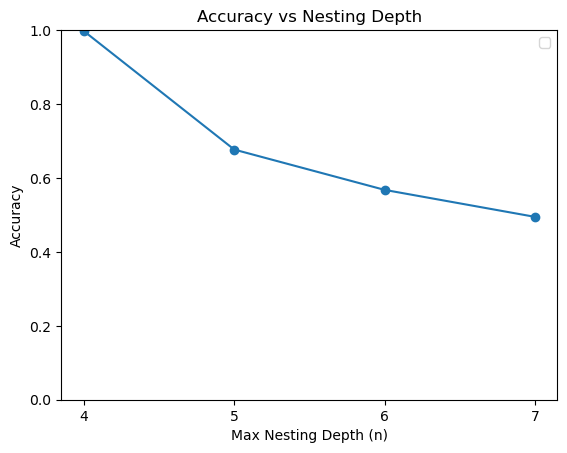

In [23]:
acc_n4 = evaluate(det_test_data_typed, model, stoi, device)

depths = [4, 5, 6, 7]
accs = [acc_n4, acc_n5, acc_n6, acc_n7]

plt.plot(depths, accs, marker="o")
plt.title("Accuracy vs Nesting Depth")
plt.xlabel("Max Nesting Depth (n)")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.ylim(0, 1)
plt.legend()
plt.savefig("../results//figures/det_ood_acc_vs_depth.pdf")
plt.show()

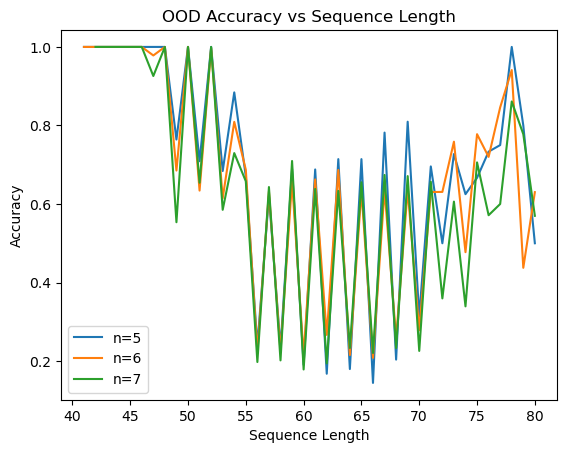

In [24]:
def evaluate_by_length(data, model, stoi, device, batch_size=64):
    model.eval()
    length_results = defaultdict(lambda: {"preds": [], "labels": []})
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            # actual length = number of non-PAD tokens
            lengths = [sum(1 for tok in x if tok != "[PAD]") for x in xs]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            for pred, label, length in zip(preds, ys, lengths):
                length_results[length]["preds"].append(pred)
                length_results[length]["labels"].append(label)

    sorted_lengths = sorted(length_results.keys())
    accs = [sum(p == l for p, l in zip(length_results[ln]["preds"], length_results[ln]["labels"])) / len(length_results[ln]["labels"]) for ln in sorted_lengths]
    return sorted_lengths, accs

lengths_n5, accs_n5 = evaluate_by_length(ood_n5, model, stoi, device)
lengths_n6, accs_n6 = evaluate_by_length(ood_n6, model, stoi, device)
lengths_n7, accs_n7 = evaluate_by_length(ood_n7, model, stoi, device)

plt.plot(lengths_n5, accs_n5, label="n=5")
plt.plot(lengths_n6, accs_n6, label="n=6")
plt.plot(lengths_n7, accs_n7, label="n=7")
plt.title("OOD Accuracy vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../results/figures/det_ood_acc_vs_length.pdf")
plt.show()

In [25]:
even_correct = [(ln, acc) for ln, acc in zip(lengths_n7, accs_n7) if ln % 2 == 0]
odd_correct = [(ln, acc) for ln, acc in zip(lengths_n7, accs_n7) if ln % 2 != 0]

print("even lengths avg acc:", sum(a for _, a in even_correct) / len(even_correct))
print("odd lengths avg acc:", sum(a for _, a in odd_correct) / len(odd_correct))

even lengths avg acc: 0.5557801405819045
odd lengths avg acc: 0.6859954411399374


In [26]:
for label, dataset in [("n=5", ood_n5), ("n=6", ood_n6), ("n=7", ood_n7)]:
    results_ood = defaultdict(lambda: {"preds": [], "labels": []})
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            types = [etype for _, _, etype in batch]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            for pred, lab, etype in zip(preds, ys, types):
                results_ood[etype]["preds"].append(pred)
                results_ood[etype]["labels"].append(lab)

    print(f"\n{label}")
    print(f"{'':>6} {'pred clean':>12} {'pred corrupted':>16}")
    for etype in ["none", "E1", "E2", "E3", "E4"]:
        preds = results_ood[etype]["preds"]
        labs = results_ood[etype]["labels"]
        pred_clean = preds.count(1)
        pred_corrupted = preds.count(0)
        acc = sum(p == l for p, l in zip(preds, labs)) / len(labs)
        print(f"{etype:>6} {pred_clean:>12} {pred_corrupted:>16}   acc={acc:.4f}")


n=5
         pred clean   pred corrupted
  none         1423             1130   acc=0.5574
    E1          230              377   acc=0.6211
    E2          250              353   acc=0.5854
    E3            1              608   acc=0.9984
    E4            5              623   acc=0.9920

n=6
         pred clean   pred corrupted
  none          965             1537   acc=0.3857
    E1          291              307   acc=0.5134
    E2          324              343   acc=0.5142
    E3            5              648   acc=0.9923
    E4            4              576   acc=0.9931

n=7
         pred clean   pred corrupted
  none          624             1854   acc=0.2518
    E1          317              314   acc=0.4976
    E2          332              298   acc=0.4730
    E3           16              632   acc=0.9753
    E4            7              606   acc=0.9886


In [27]:
# check label distribution by length
length_label_dist = defaultdict(lambda: {"clean": 0, "corrupted": 0})

for x, y, etype in ood_n7:
    length = sum(1 for tok in x if tok != "[PAD]")
    if y == 1:
        length_label_dist[length]["clean"] += 1
    else:
        length_label_dist[length]["corrupted"] += 1

print(f"{'length':>8} {'clean':>8} {'corrupted':>12} {'% corrupted':>14}")
for ln in sorted(length_label_dist.keys()):
    clean = length_label_dist[ln]["clean"]
    corrupted = length_label_dist[ln]["corrupted"]
    total = clean + corrupted
    print(f"{ln:>8} {clean:>8} {corrupted:>12} {corrupted/total*100:>13.1f}%")

  length    clean    corrupted    % corrupted
      42        0            1         100.0%
      43        0            1         100.0%
      44        3            0           0.0%
      46       16            5          23.8%
      47        0           27         100.0%
      48       50           16          24.2%
      49        0           56         100.0%
      50      103           31          23.1%
      51        0          107         100.0%
      52      177           52          22.7%
      53        0          135         100.0%
      54      206           64          23.7%
      55        0          190         100.0%
      56      265           64          19.5%
      57        0          227         100.0%
      58      281           71          20.2%
      59        0          210         100.0%
      60      299           65          17.9%
      61        0          188         100.0%
      62      245           59          19.4%
      63        0          150    